<a href="https://colab.research.google.com/github/enriquefroes/atletico-arena-mrv/blob/main/notebooks/02_mata_mata_e_jogos_grandes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/analise_arena_mrv'
except ImportError:
    BASE = './analise_arena_mrv'

DADOS, GRAF, TAB = (os.path.join(BASE, p) for p in ['dados', 'graficos', 'tabelas'])
for p in (GRAF, TAB):
    os.makedirs(p, exist_ok=True)
if not os.path.exists(os.path.join(DADOS, 'jogos_arena_mrv.csv')):
    raise FileNotFoundError('Rode primeiro o notebook 00_dados.ipynb')
jogos = pd.read_csv(os.path.join(DADOS, 'jogos_arena_mrv.csv'), parse_dates=['data'])
jogos['mata_mata'] = jogos['fase'].str.contains('mata-mata')

PRETO, CINZA, VERDE, VERMELHO, AMARELO = '#111111', '#9ca3af', '#16a34a', '#dc2626', '#eab308'

def resumo(df, por=None):
    g = df.groupby(por) if por else df.groupby(lambda _: 'Total')
    r = g.agg(jogos=('pontos', 'size'), vitorias=('resultado', lambda s: (s == 'V').sum()),
              empates=('resultado', lambda s: (s == 'E').sum()), derrotas=('resultado', lambda s: (s == 'D').sum()),
              gols_pro=('gols_pro', 'sum'), gols_contra=('gols_contra', 'sum'), pontos=('pontos', 'sum'))
    r['aproveitamento'] = (r['pontos'] / (3 * r['jogos']) * 100).round(1)
    return r

def barras_vde(r, titulo, arquivo, ordenar=True):
    """Barras empilhadas de vitórias, empates e derrotas, com o aproveitamento ao lado."""
    t = r.sort_values('aproveitamento') if ordenar else r.iloc[::-1]
    fig, ax = plt.subplots(figsize=(11, max(3, 0.6 * len(t) + 1.5)))
    esq = np.zeros(len(t))
    for col, cor, nome in [('vitorias', VERDE, 'Vitórias'), ('empates', CINZA, 'Empates'), ('derrotas', VERMELHO, 'Derrotas')]:
        ax.barh(t.index.astype(str), t[col], left=esq, color=cor, label=nome)
        for i, (v, e) in enumerate(zip(t[col], esq)):
            if v > 0:
                ax.text(e + v / 2, i, int(v), ha='center', va='center', color='white', fontsize=9, fontweight='bold')
        esq += t[col].values
    for i, (tot, a) in enumerate(zip(t['jogos'], t['aproveitamento'])):
        ax.text(tot + 0.3, i, f'{a:.1f}%  ({tot} j)', va='center', fontsize=10, fontweight='bold')
    ax.set_xlim(0, t['jogos'].max() * 1.25)
    ax.set_xlabel('Jogos')
    ax.set_title(titulo, fontsize=12)
    ax.legend(loc='lower right', fontsize=9)
    salvar(arquivo)

def salvar(nome):
    plt.tight_layout()
    plt.savefig(os.path.join(GRAF, nome), dpi=150, bbox_inches='tight')
    plt.show()
    print('Salvo em', os.path.join(GRAF, nome))

Mounted at /content/drive


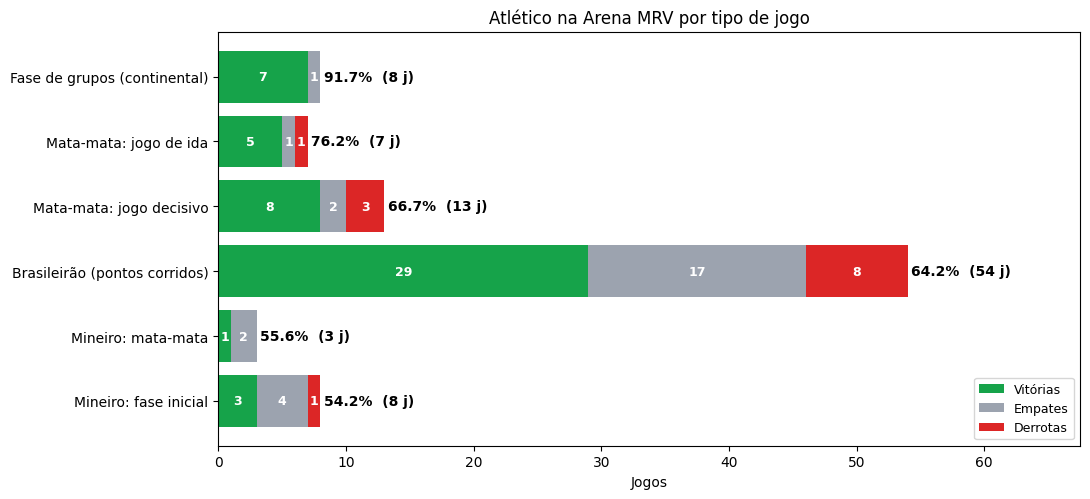

Salvo em /content/drive/MyDrive/analise_arena_mrv/graficos/02a_por_tipo_de_jogo.png


,jogos,vitorias,empates,derrotas,gols_pro,gols_contra,pontos,aproveitamento
tipo,,,,,,,,
Brasileirão (pontos corridos),54,29,17,8,90,58,104,64.2
Fase de grupos (continental),8,7,1,0,18,6,22,91.7
Mata-mata: jogo de ida,7,5,1,1,11,5,16,76.2
Mata-mata: jogo decisivo,13,8,2,3,22,9,26,66.7
Mineiro: fase inicial,8,3,4,1,12,6,13,54.2
Mineiro: mata-mata,3,1,2,0,5,3,5,55.6


In [2]:
tipo = np.select(
    [jogos['fase'] == 'mata-mata decisivo', jogos['fase'] == 'mata-mata ida', jogos['fase'].str.startswith('estadual mata-mata'),
     jogos['fase'] == 'fase de grupos', jogos['fase'] == 'estadual (fase inicial)'],
    ['Mata-mata: jogo decisivo', 'Mata-mata: jogo de ida', 'Mineiro: mata-mata', 'Fase de grupos (continental)', 'Mineiro: fase inicial'],
    default='Brasileirão (pontos corridos)')
jogos['tipo'] = tipo
t = resumo(jogos, 'tipo')
t.to_csv(os.path.join(TAB, '02_por_tipo_de_jogo.csv'))
barras_vde(t, 'Atlético na Arena MRV por tipo de jogo', '02a_por_tipo_de_jogo.png')
t

Confrontos decididos na Arena: 13 · avançou em 12 (92.3%)
Desses, avançou SEM vencer o jogo da Arena: 4
      data     competicao              adversario  gols_pro  gols_contra            confronto         treinador
2024-08-07 Copa do Brasil                     CRB         3            0              avançou    Gabriel Milito
2024-08-20   Libertadores             San Lorenzo         1            0              avançou    Gabriel Milito
2024-09-12 Copa do Brasil               São Paulo         0            0              avançou    Gabriel Milito
2024-09-25   Libertadores              Fluminense         2            0              avançou    Gabriel Milito
2024-11-10 Copa do Brasil                Flamengo         0            1     eliminado (vice)    Gabriel Milito
2025-05-21 Copa do Brasil                 Maringá         4            0              avançou              Cuca
2025-07-24  Sul-Americana             Bucaramanga         0            1 avançou nos pênaltis              Cuca


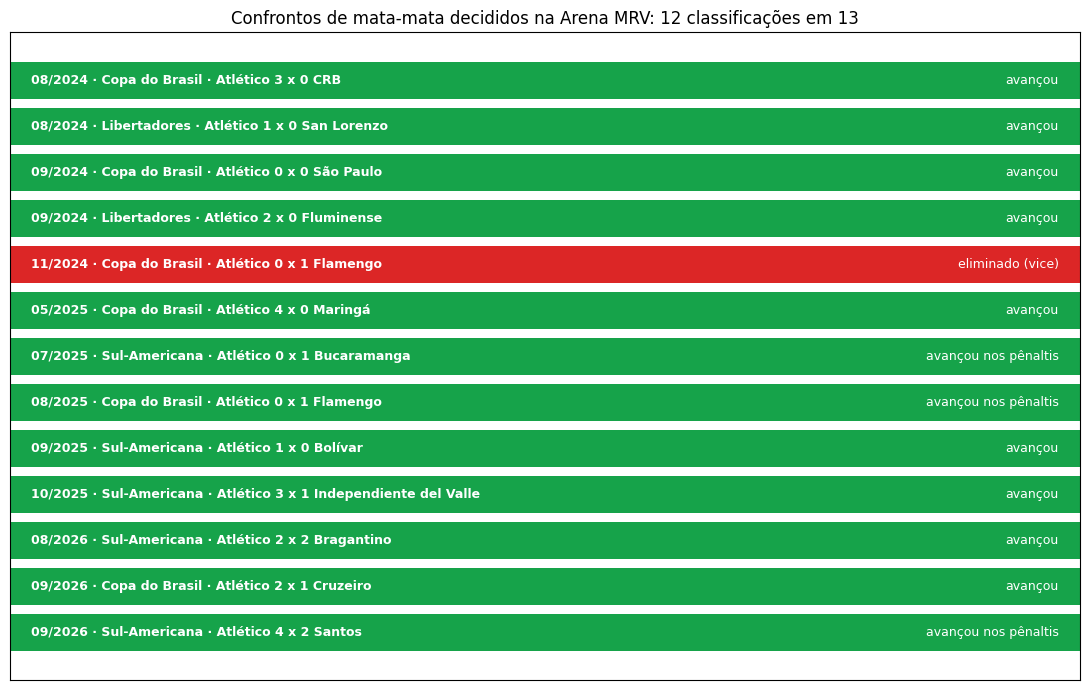

Salvo em /content/drive/MyDrive/analise_arena_mrv/graficos/02b_confrontos_decididos.png


In [3]:
dec = jogos[jogos['fase'] == 'mata-mata decisivo'].sort_values('data')
avancou = dec['confronto'].str.startswith('avançou').sum()
print(f"Confrontos decididos na Arena: {len(dec)} · avançou em {avancou} ({avancou/len(dec)*100:.1f}%)")
print(f"Desses, avançou SEM vencer o jogo da Arena: {(dec['confronto'].str.startswith('avançou') & (dec['resultado'] != 'V')).sum()}")
print(dec[['data', 'competicao', 'adversario', 'gols_pro', 'gols_contra', 'confronto', 'treinador']].to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 7))
for i, (_, x) in enumerate(dec.iloc[::-1].iterrows()):
    cor = VERDE if x['confronto'].startswith('avançou') else VERMELHO
    ax.barh(i, 1, color=cor)
    ax.text(0.02, i, f"{x['data']:%m/%Y} · {x['competicao']} · Atlético {x['gols_pro']} x {x['gols_contra']} {x['adversario']}",
            va='center', color='white', fontsize=9, fontweight='bold')
    ax.text(0.98, i, x['confronto'], va='center', ha='right', color='white', fontsize=9)
ax.set_xlim(0, 1); ax.set_yticks([]); ax.set_xticks([])
ax.set_title(f'Confrontos de mata-mata decididos na Arena MRV: {avancou} classificações em {len(dec)}', fontsize=12)
salvar('02b_confrontos_decididos.png')

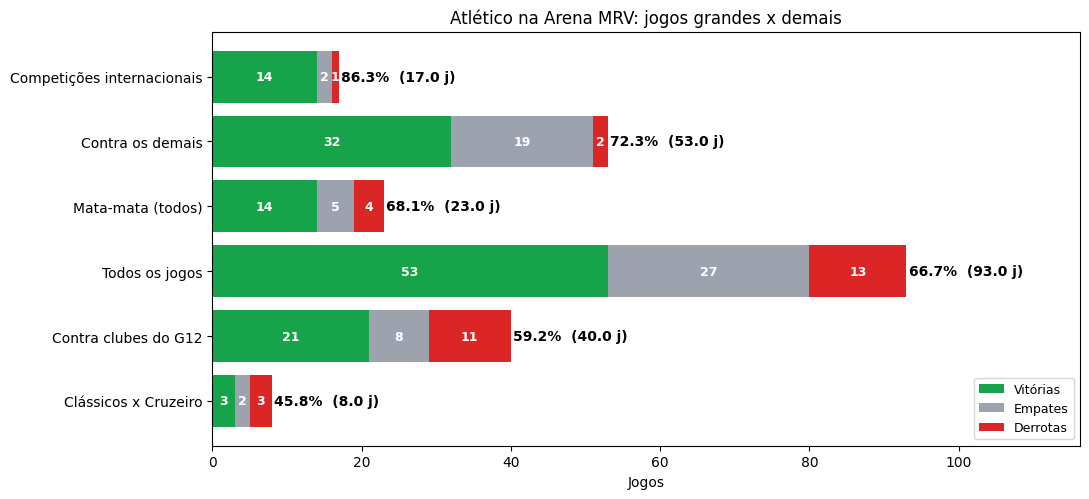

Salvo em /content/drive/MyDrive/analise_arena_mrv/graficos/02c_jogos_grandes.png
Das 13 derrotas na Arena, 11 foram para clubes do G12:
      data     competicao    adversario  gols_pro  gols_contra
2023-10-08    Brasileirão      Coritiba         1            2
2023-10-22    Brasileirão      Cruzeiro         0            1
2024-02-03        Mineiro      Cruzeiro         0            2
2024-06-17    Brasileirão     Palmeiras         0            4
2024-07-03    Brasileirão      Flamengo         2            4
2024-10-26    Brasileirão Internacional         1            3
2024-11-10 Copa do Brasil      Flamengo         0            1
2025-07-24  Sul-Americana   Bucaramanga         0            1
2025-08-06 Copa do Brasil      Flamengo         0            1
2025-08-17    Brasileirão        Grêmio         1            3
2025-08-27 Copa do Brasil      Cruzeiro         0            2
2025-12-03    Brasileirão     Palmeiras         0            3
2026-04-26    Brasileirão      Flamengo      

,jogos,vitorias,empates,derrotas,gols_pro,gols_contra,pontos,aproveitamento
Todos os jogos,93.0,53.0,27.0,13.0,158.0,87.0,186.0,66.7
Contra clubes do G12,40.0,21.0,8.0,11.0,61.0,47.0,71.0,59.2
Contra os demais,53.0,32.0,19.0,2.0,97.0,40.0,115.0,72.3
Clássicos x Cruzeiro,8.0,3.0,2.0,3.0,10.0,10.0,11.0,45.8
Competições internacionais,17.0,14.0,2.0,1.0,36.0,13.0,44.0,86.3
Mata-mata (todos),23.0,14.0,5.0,4.0,38.0,17.0,47.0,68.1


In [4]:
recortes = {
    'Todos os jogos': jogos,
    'Contra clubes do G12': jogos[jogos['adversario_g12'] == 'sim'],
    'Contra os demais': jogos[jogos['adversario_g12'] == 'nao'],
    'Clássicos x Cruzeiro': jogos[jogos['classico'] == 'sim'],
    'Competições internacionais': jogos[jogos['internacional'] == 'sim'],
    'Mata-mata (todos)': jogos[jogos['mata_mata']],
}
g = pd.concat({k: resumo(v).iloc[0] for k, v in recortes.items()}, axis=1).T
g.to_csv(os.path.join(TAB, '02_jogos_grandes.csv'))
barras_vde(g, 'Atlético na Arena MRV: jogos grandes x demais', '02c_jogos_grandes.png')
der = jogos[jogos['resultado'] == 'D']
print(f"Das {len(der)} derrotas na Arena, {(der['adversario_g12'] == 'sim').sum()} foram para clubes do G12:")
print(der[['data', 'competicao', 'adversario', 'gols_pro', 'gols_contra']].to_string(index=False))
g

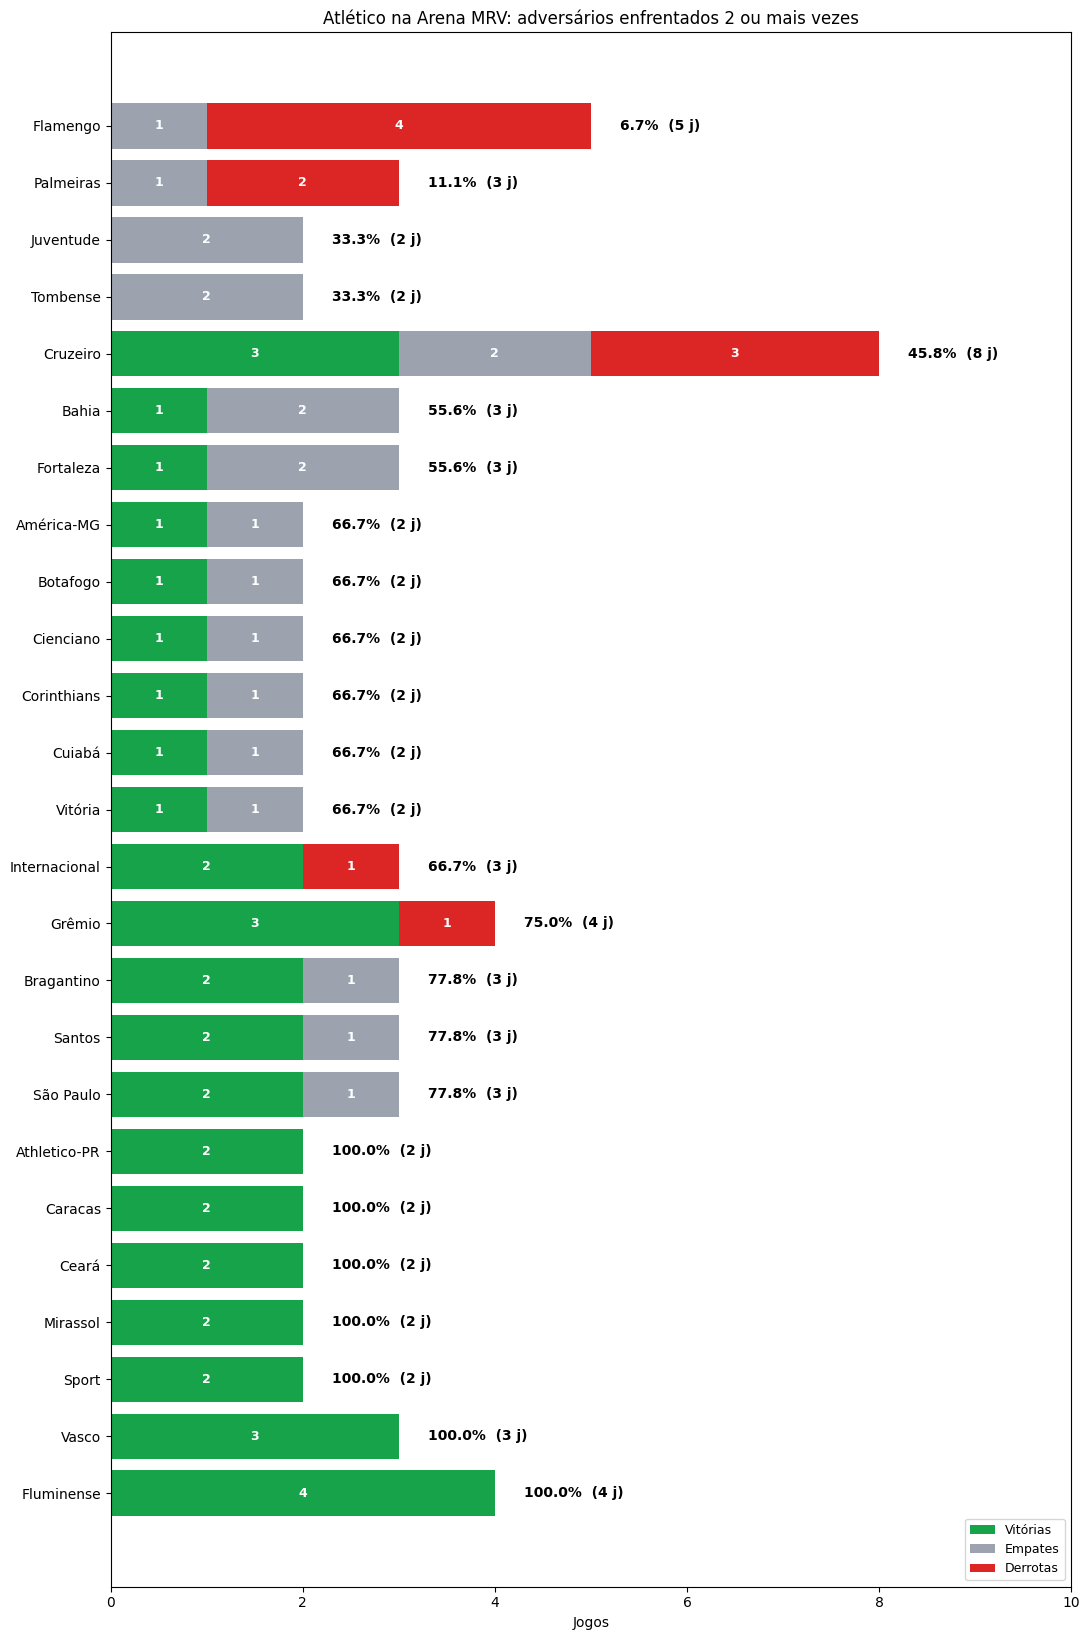

Salvo em /content/drive/MyDrive/analise_arena_mrv/graficos/02d_por_adversario.png


In [5]:
adv = resumo(jogos, 'adversario')
adv = adv[adv['jogos'] >= 2].sort_values(['aproveitamento', 'jogos'], ascending=[True, True])
adv.to_csv(os.path.join(TAB, '02_por_adversario.csv'))
barras_vde(adv, 'Atlético na Arena MRV: adversários enfrentados 2 ou mais vezes', '02d_por_adversario.png', ordenar=False)